### Explorative Analyse der Smartmeter Daten

In [6]:
import sys
import os
sys.path.append(os.path.abspath("../src"))

from data_loader import processed_data_load
import seaborn as sns
import matplotlib as plt
import polars as pl

In [10]:
combined_data = processed_data_load(path ='./data/processed/combined_data.csv')
combined_data

❌ Fehler beim Laden der Processed Data: name 'file_path' is not defined


shape: (0, 0)
┌┐
╞╡
└┘

C:\Users\maxkr\AppData\Local\Temp\ipykernel_26296\1945439464.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.to_pandas(), x="heatpump_installation_type", y="heatpump_installation_normpoint_cop",


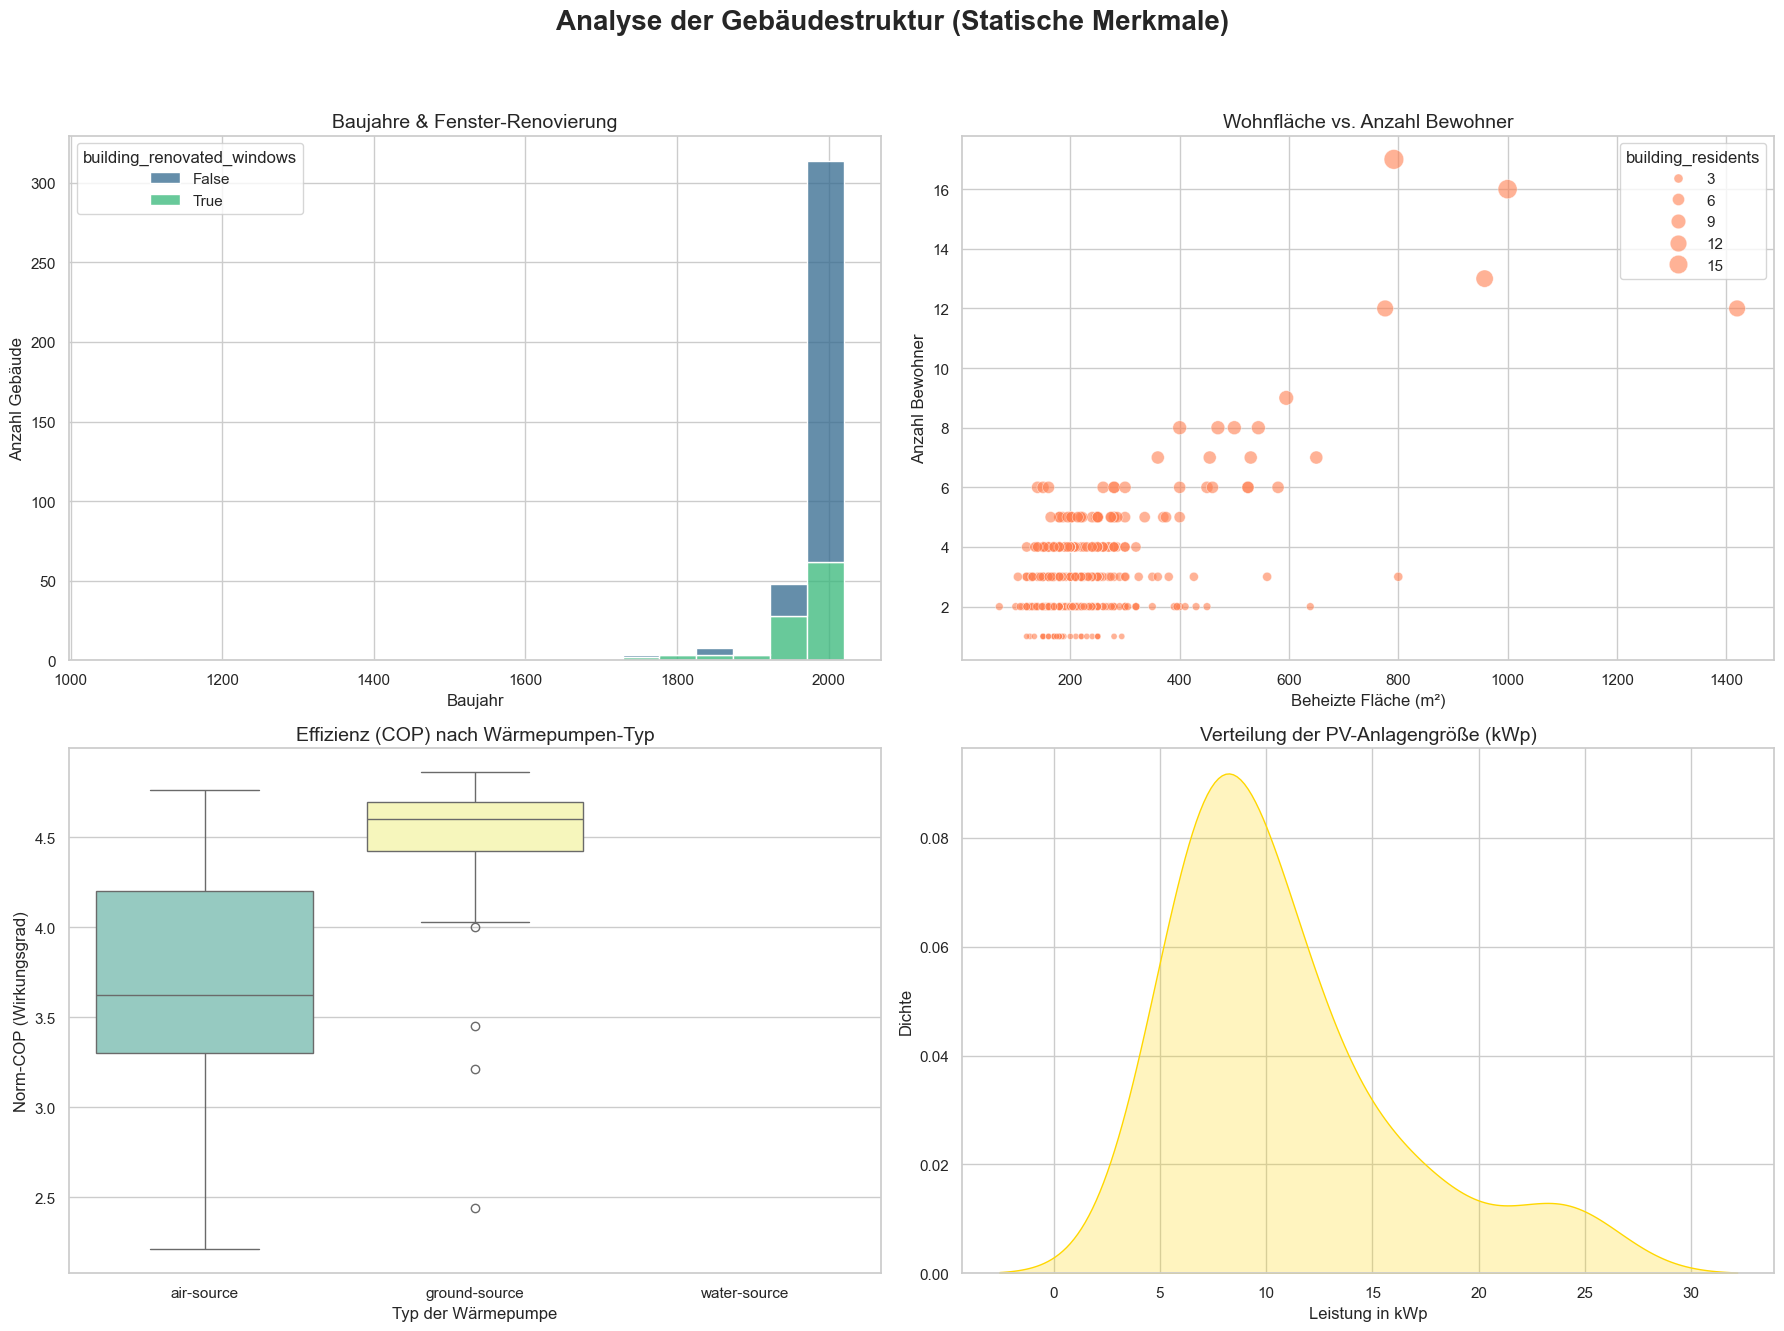

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

def plot_building_analysis(df: pl.DataFrame):
    # Styling
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle("Analyse der Gebäudestruktur (Statische Merkmale)", fontsize=20, fontweight='bold')

    # 1. Baujahr & Renovierungsstatus
    # Wir kombinieren das Baujahr mit der Info, ob Fenster renoviert wurden
    plt.subplot(2, 2, 1)
    sns.histplot(data=df.to_pandas(), x="building_constructionyear", hue="building_renovated_windows", 
                 multiple="stack", palette="viridis", bins=20)
    plt.title("Baujahre & Fenster-Renovierung", fontsize=14)
    plt.xlabel("Baujahr")
    plt.ylabel("Anzahl Gebäude")

    # 2. Beheizte Fläche vs. Anzahl Bewohner
    # Wichtig für den Warmwasserverbrauch (DHW)
    plt.subplot(2, 2, 2)
    sns.scatterplot(data=df.to_pandas(), x="building_floorareaheated_total", y="building_residents", 
                    alpha=0.6, size="building_residents", sizes=(20, 200), color="coral")
    plt.title("Wohnfläche vs. Anzahl Bewohner", fontsize=14)
    plt.xlabel("Beheizte Fläche (m²)")
    plt.ylabel("Anzahl Bewohner")

    # 3. Wärmepumpen-Technologie nach COP (Wirkungsgrad)
    plt.subplot(2, 2, 3)
    sns.boxplot(data=df.to_pandas(), x="heatpump_installation_type", y="heatpump_installation_normpoint_cop", 
                palette="Set3")
    plt.title("Effizienz (COP) nach Wärmepumpen-Typ", fontsize=14)
    plt.xlabel("Typ der Wärmepumpe")
    plt.ylabel("Norm-COP (Wirkungsgrad)")

    # 4. PV-Größe Verteilung (für die Haushalte mit PV)
    plt.subplot(2, 2, 4)
    pv_data = df.filter(pl.col("building_pvsystem_size") > 0).to_pandas()
    sns.kdeplot(data=pv_data, x="building_pvsystem_size", fill=True, color="gold")
    plt.title("Verteilung der PV-Anlagengröße (kWp)", fontsize=14)
    plt.xlabel("Leistung in kWp")
    plt.ylabel("Dichte")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Aufruf mit deinem Metadaten-DataFrame
plot_building_analysis(household_info)

C:\Users\maxkr\AppData\Local\Temp\ipykernel_26296\1298940223.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


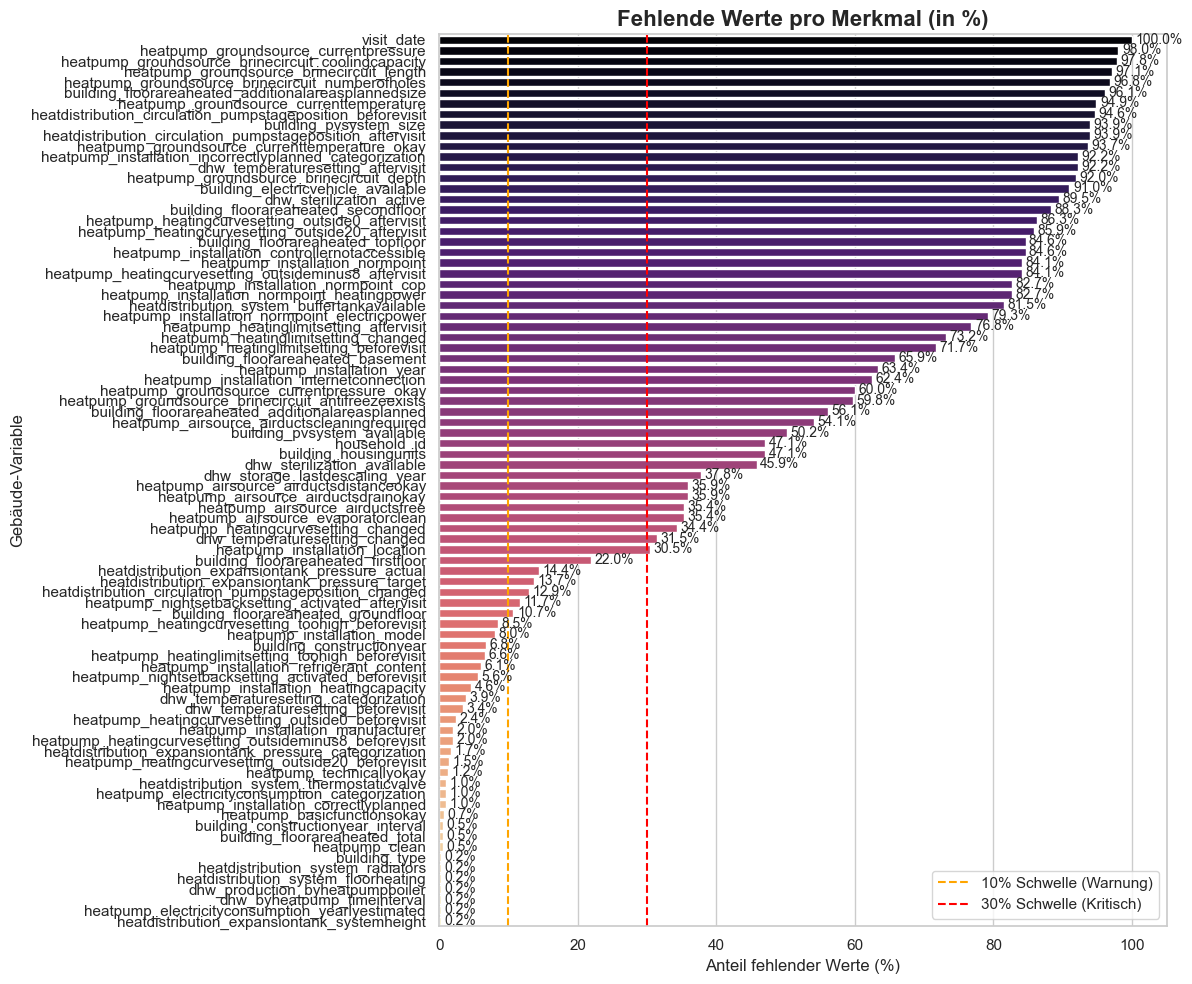

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

def plot_missing_values(df: pl.DataFrame):
    # 1. Prozentsatz der fehlenden Werte pro Spalte berechnen
    missing_data = df.select([
        (pl.col(c).null_count() / df.height * 100).alias(c)
        for c in df.columns
    ]).unpivot(variable_name="Spalte", value_name="Prozent_Fehlend")

    # 2. Nur Spalten mit fehlenden Werten anzeigen und sortieren
    missing_data = (
        missing_data
        .filter(pl.col("Prozent_Fehlend") > 0)
        .sort("Prozent_Fehlend", descending=True)
    )

    if missing_data.is_empty():
        print("✅ Hervorragend! Keine fehlenden Werte in diesem Datensatz gefunden.")
        return

    # 3. Visualisierung
    plt.figure(figsize=(12, 10))
    sns.set_theme(style="whitegrid")
    
    # Balkendiagramm erstellen
    ax = sns.barplot(
        data=missing_data.to_pandas(), 
        x="Prozent_Fehlend", 
        y="Spalte", 
        palette="magma"
    )

    # Hilfslinien für kritische Schwellenwerte
    plt.axvline(x=10, color='orange', linestyle='--', label='10% Schwelle (Warnung)')
    plt.axvline(x=30, color='red', linestyle='--', label='30% Schwelle (Kritisch)')
    
    plt.title("Fehlende Werte pro Merkmal (in %)", fontsize=16, fontweight='bold')
    plt.xlabel("Anteil fehlender Werte (%)", fontsize=12)
    plt.ylabel("Gebäude-Variable", fontsize=12)
    plt.legend(loc='lower right')
    
    # Prozentzahlen an die Balken schreiben
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.1f}%', 
                    (p.get_width() + 0.5, p.get_y() + p.get_height() / 2), 
                    va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

# Anwendung auf deine Gebäude-Info:
plot_missing_values(household_info)